In [ ]:
# Get heart disease dataset

from ucimlrepo import fetch_ucirepo
import pandas as pd

heart_disease = fetch_ucirepo(id=45) 

X = heart_disease.data.features 
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [ ]:
# Data exploration

print('Num Samples:', len(df))
print('Num Cols:', len(df.columns))

print('Columns:', df.columns.tolist())

print('Min num:', df['num'].min())
print('Max num:', df['num'].max())

print('Num has disease:', (df['num'] > 0).sum())

print('Missing values:', df.isnull().sum().sum())

Num Samples: 303
Num Cols: 14
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Min num: 0
Max num: 4
Num has disease: 139
Missing values: 6


In [9]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      0.994971   22.8750

In [12]:
# Data Preprocessing: Drops missing values and scales cols, and marks samples with disease
from sklearn.preprocessing import StandardScaler

df = df.dropna()

scaled_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

df['has_disease'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print('After preprocessing:')
print('Num Samples:', len(df))
print(df.describe())

After preprocessing:
Num Samples: 297
                age         sex          cp      trestbps          chol  \
count  2.970000e+02  297.000000  297.000000  2.970000e+02  2.970000e+02   
mean   1.644775e-17    0.676768    3.158249  4.485750e-17 -5.980999e-18   
std    1.001688e+00    0.468500    0.964859  1.001688e+00  1.001688e+00   
min   -2.827176e+00    0.000000    1.000000 -2.125634e+00 -2.337704e+00   
25%   -7.241238e-01    0.000000    3.000000 -6.594306e-01 -7.002541e-01   
50%    1.613719e-01    1.000000    3.000000 -9.550637e-02 -8.380217e-02   
75%    7.148067e-01    1.000000    4.000000  4.684179e-01  5.519138e-01   
max    2.485798e+00    1.000000    4.000000  3.851964e+00  6.099981e+00   

              fbs     restecg       thalach       exang     oldpeak  \
count  297.000000  297.000000  2.970000e+02  297.000000  297.000000   
mean     0.144781    0.996633  4.784800e-17    0.326599    0.000000   
std      0.352474    0.994914  1.001688e+00    0.469761    1.001688   
mi

In [31]:
# Data Split

from sklearn.model_selection import train_test_split, StratifiedKFold

X = df.drop(columns=['has_disease'])
y = df['has_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Train samples:', len(X_train))
print('Test samples:', len(X_test))

Train samples: 207
Test samples: 90


In [32]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

c_grid = np.logspace(-3, 3, 13)

# Logistic Regression
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid={'C': c_grid}, cv=cv, scoring='roc_auc')
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression:', lr_grid.best_params_)

# Lasso Logistic Regression
lasso_grid = GridSearchCV(LogisticRegression(max_iter=1000, penalty='l1', solver='saga'), param_grid={'C': c_grid}, cv=cv, scoring='roc_auc')
lasso_grid.fit(X_train, y_train)

print('Best Lasso Logistic Regression:', lasso_grid.best_params_)

Best Logistic Regression: {'C': np.float64(0.1)}
Best Lasso Logistic Regression: {'C': np.float64(10.0)}


In [33]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid={'n_neighbors': list(range(1, 21))}, cv=cv, scoring='roc_auc')
knn_grid.fit(X_train, y_train)

print('Best KNN:', knn_grid.best_params_)

Best KNN: {'n_neighbors': 20}


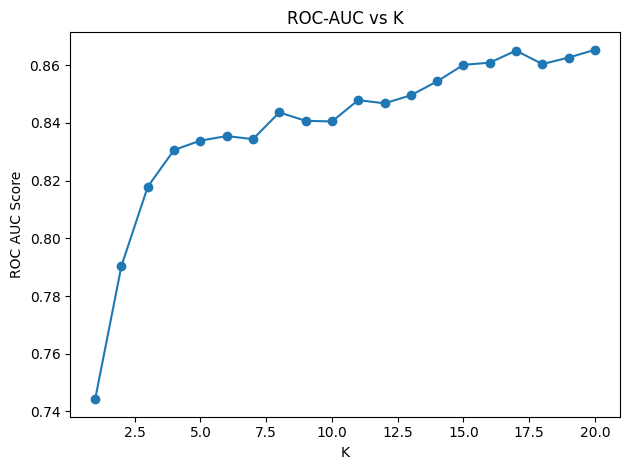

In [34]:
import matplotlib.pyplot as plt

knn_results = pd.DataFrame(knn_grid.cv_results_)

plt.plot(knn_results['param_n_neighbors'], knn_results['mean_test_score'], marker='o')

plt.title('ROC-AUC vs K')
plt.xlabel('K')
plt.ylabel('ROC AUC Score')
plt.tight_layout()
plt.show()

In [35]:
# Evaluation Summary

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

models = {
    'Logistic (L2)': lr_grid.best_estimator_,
    'Lasso (L1)':    lasso_grid.best_estimator_,
    'KNN':           knn_grid.best_estimator_,
}

rows = []
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, pred),
        'ROC-AUC':  roc_auc_score(y_test, proba),
        'F1':       f1_score(y_test, pred),
    })

summary = pd.DataFrame(rows).set_index('Model').round(3)
print(summary)

               Accuracy  ROC-AUC     F1
Model                                  
Logistic (L2)     0.856    0.938  0.840
Lasso (L1)        0.844    0.945  0.825
KNN               0.811    0.902  0.790


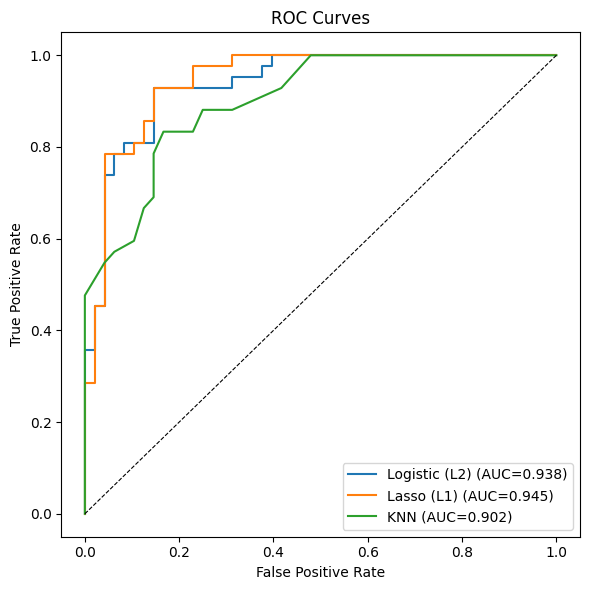

In [36]:
# ROC Curves

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(6, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
plt.tight_layout()
plt.show()

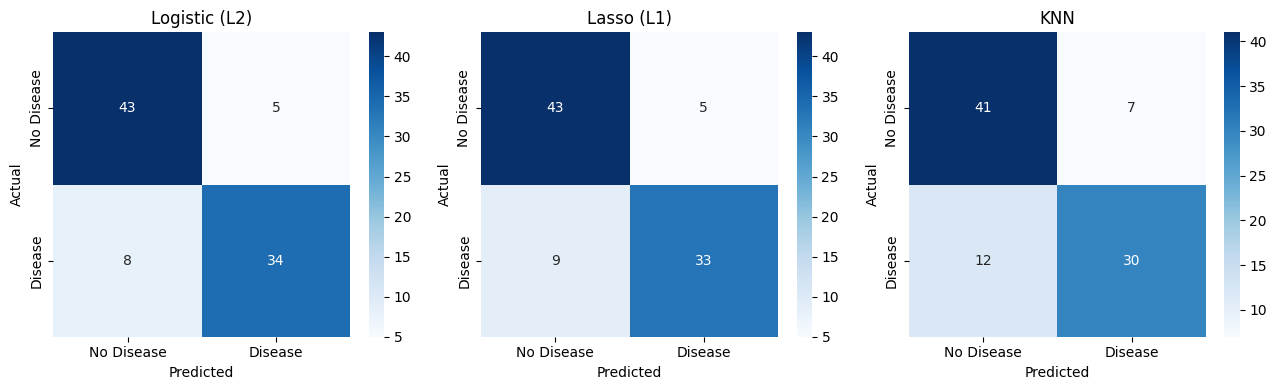

In [37]:
# Confusion Matrices

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()